In [20]:
import pandas as pd
import numpy as pn
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [21]:
df=pd.read_csv('data/Students.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [22]:
df.shape

(1000, 8)

In [23]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [26]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [27]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [28]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [29]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [30]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [31]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [32]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [33]:
numeric_feature=[features for features in df.columns if df[features].dtype != 'object']
categorical_feature=[features for features in df.columns if df[features].dtype == 'object']

print("'we have {} numerical features :{}".format(len(numeric_feature),numeric_feature))
print("'we have {} categorical features :{}".format(len(categorical_feature),categorical_feature))

'we have 3 numerical features :['math score', 'reading score', 'writing score']
'we have 5 categorical features :['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [34]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [35]:
df['total score']=df['math score']+df['reading score']+df['writing score']
df['avg score']=df['total score']/3
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,avg score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [38]:
reading_full=df[df['reading score']==100]['avg score'].count()
math_full=df[df['math score']==100]['avg score'].count()
writing_full=df[df['writing score']==100]['avg score'].count()

In [39]:
print(f"num of student who get full marks in reading is:{reading_full}")
print(f"num of student who get full marks in math is:{math_full}")
print(f"num of student who get full marks in writing is:{writing_full}")

num of student who get full marks in reading is:17
num of student who get full marks in math is:7
num of student who get full marks in writing is:14


In [41]:
reading_less_20=df[df['reading score']<=20]['avg score'].count()
math_less_20=df[df['math score']<=20]['avg score'].count()
writing_less_20=df[df['writing score']<=20]['avg score'].count()

In [42]:
print(f"num of student who scored less than 20 in reading is:{reading_less_20}")
print(f"num of student who scored less than 20 in math is:{math_less_20}")
print(f"num of student who scored less than 20 in writing is:{writing_less_20}")

num of student who scored less than 20 in reading is:1
num of student who scored less than 20 in math is:4
num of student who scored less than 20 in writing is:3


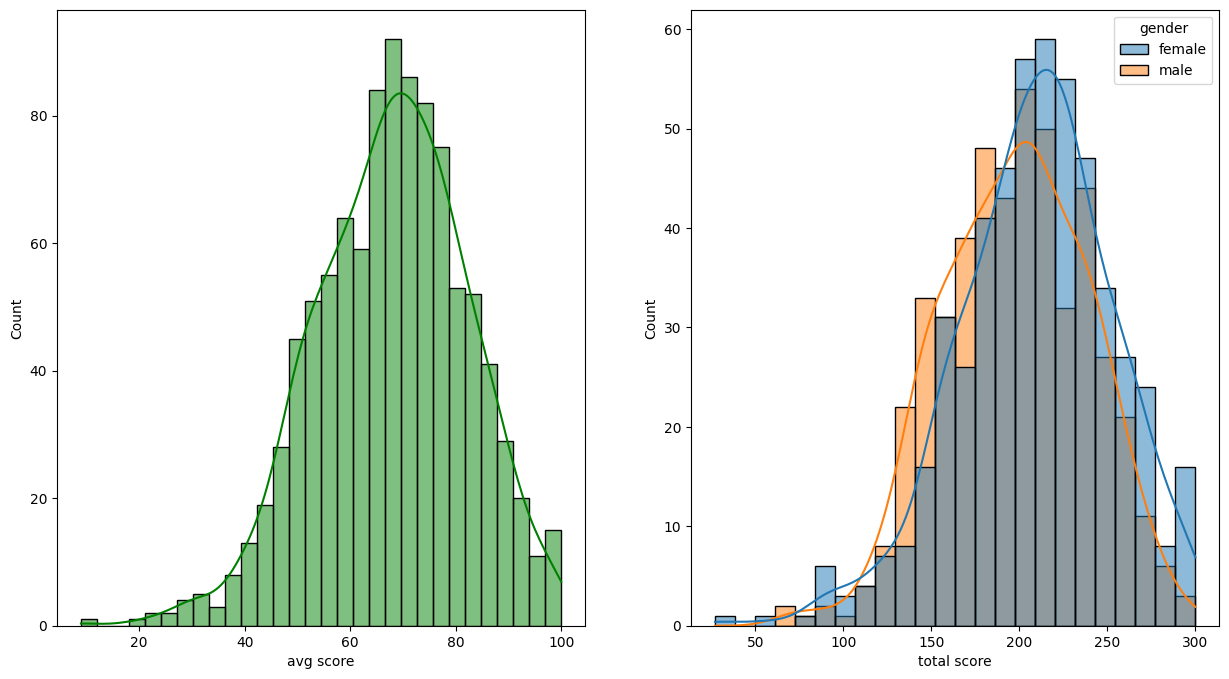

In [43]:
fig,axs=plt.subplots(1,2,figsize=(15,8))
plt.subplot(121)
sns.histplot(data=df,x='avg score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

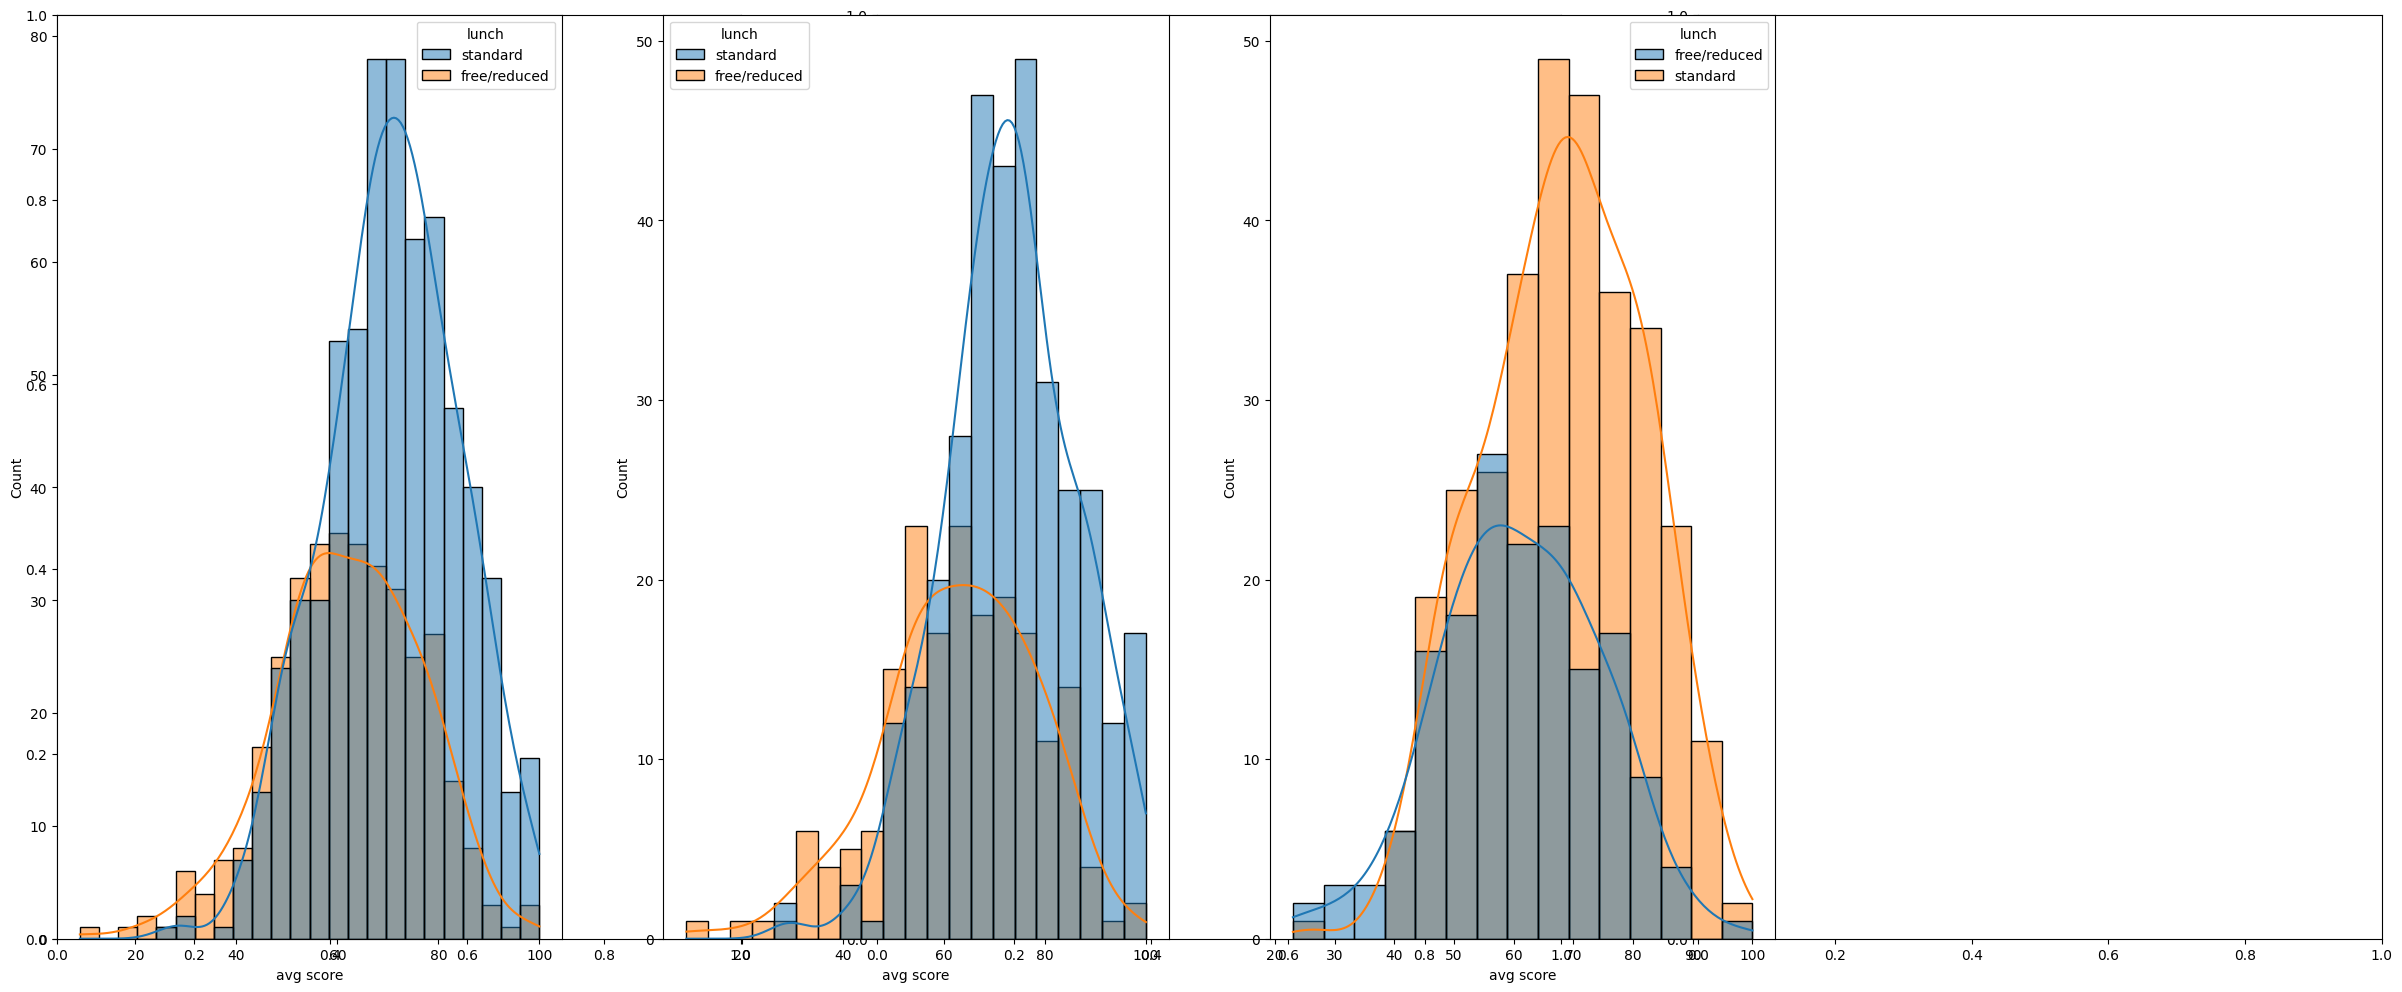

In [48]:
plt.subplots(1,3,figsize=(30,12))
plt.subplot(141)
sns.histplot(data=df,x='avg score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='avg score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='avg score',kde=True,hue='lunch')
plt.show()